In [1]:
import sys
sys.path.insert(0, "/srv/user/azhar.akhmetova/corrViT/analysis/src")
import os
import pickle
import matplotlib
import torch
import numpy as np
import typing as t
import argparse
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.ndimage import center_of_mass

from v1t.utils import utils, tensorboard
from v1t import data
from v1t.models.model import Model
from v1t.utils.scheduler import Scheduler
from v1t.utils.neuron_representations import sample_neuron_tokens

from torch.utils.data import DataLoader

utils.set_random_seed(1234)

tensorboard.set_font()

## Load the model

In [2]:
output_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_5_2dpe_bef_core"

In [3]:
parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/corrViT/refactor/data/sensorium")
parser.add_argument("--output_dir", type=str, required=True)
parser.add_argument("--batch_size", type=int, default=1)
parser.add_argument("--device", type=str, default="cpu")
parser.add_argument("--frac_input_neurons", type=float, default=0.)

args = parser.parse_args([
    "--frac_input_neurons", "1.",
    "--output_dir", f"{output_dir}",
])

In [4]:
if not os.path.isdir(args.output_dir):
    raise FileNotFoundError(f"Cannot find {args.output_dir}.")

utils.get_device(args)
utils.set_random_seed(1234)

utils.load_args(args)

train_ds, val_ds, test_ds = data.get_training_ds(
    args,
    data_dir=args.dataset,
    mouse_ids=args.mouse_ids,
    batch_size=args.batch_size,
    device=args.device,
)

model = Model(args, ds=val_ds)
model.eval()

scheduler = Scheduler(args, model=model, save_optimizer=False)
scheduler.restore(force=True)

image shape (1, 144, 256)
num_output_neurons {'k_4_a_03_xyz_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: ['neuron_coord_pe.weight', 'neuron_coord_pe.bias', 'projection_query_pe.weight', 'projection_query_pe.bias']

Loaded checkpoint from epoch 58 (correlation: 0.6619).



/srv/user/azhar.akhmetova/corrViT/analysis/src/v1t/utils/scheduler.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_location=self.device

58

In [5]:
mouse_key = args.mouse_ids[0]

## Pytorch Linear probe

In [6]:
import random
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import pathlib
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import sampler


In [7]:
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cuda:0


In [13]:
def get_neuron_indices(rep_dir, neuron_fraction=1.0, neuron_seed=42, save_folder=None):
    """Get neuron indices for nested subsampling"""
    # Try to load existing indices
    if save_folder is not None:
        file_path = os.path.join(save_folder, f"input_frac_{neuron_fraction:.3f}_seed_{neuron_seed}.pkl")
        try:
            with open(file_path, 'rb') as f:
                neuron_data = pickle.load(f)
            input_indices = neuron_data['input_neuron_indices']
            query_indices = neuron_data['query_neuron_indices']
            print(f"Loaded input/query neuron indices from {file_path}")
            
            # Get N from first training file (for verification)
            train_dir = os.path.join(rep_dir, 'train')
            fnames = sorted([f for f in os.listdir(train_dir) if f.endswith('.npy')], 
                           key=lambda x: int(x.split('.')[0]))  # Consistent sorting
            first_file = fnames[0]
            first_arr = np.load(os.path.join(train_dir, first_file), mmap_mode='r')
            N = first_arr.shape[1]  # number of neurons
            
            # Verify loaded data is consistent
            if neuron_data['total_neurons'] != N:
                print(f"Warning: Loaded N={neuron_data['total_neurons']} but current data has N={N}")
            
            return input_indices, query_indices, N
            
        except (FileNotFoundError, KeyError, pickle.UnpicklingError) as e:
            print(f"Could not load existing indices ({e}), generating new ones...")

    train_dir = os.path.join(rep_dir, 'train')
    first_file = os.listdir(train_dir)[0]
    first_arr = np.load(os.path.join(train_dir, first_file), mmap_mode='r')
    N = first_arr.shape[1]  # number of neurons
    
    # create nested neuron indices (reproducible)
    np.random.seed(neuron_seed)
    all_indices = np.random.permutation(N)
    n_neurons = int(N * neuron_fraction)

    # input neurons
    input_indices = np.sort(all_indices[:n_neurons])

    # complement = query neurons
    mask = np.ones(N, dtype=bool)
    mask[input_indices] = False
    query_indices = np.nonzero(mask)[0]

    print(f"Selected {n_neurons}/{N} neurons ({neuron_fraction*100:.1f}%) "
        f"with seed {neuron_seed}")
    if save_folder is not None:
        neuron_data = {
            'input_neuron_indices': input_indices,
            'query_neuron_indices': query_indices,
            'neuron_fraction': neuron_fraction,
            'neuron_seed': neuron_seed,
            'total_neurons': N,
            'n_selected': n_neurons
        }
        
        # Create filename
        filename = f"input_frac_{neuron_fraction:.2f}_seed_{neuron_seed}.pkl"
        filepath = os.path.join(save_folder, filename)
        os.makedirs(save_folder, exist_ok=True)
        
        with open(filepath, 'wb') as f:
            pickle.dump(neuron_data, f)
    return input_indices, query_indices, N

In [9]:
rep_dir = args.output_dir  + "/neuron_token_representations/k_4_a_03_xyz_b1e7_poisson/initial"

In [14]:
for frac in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:    
    input_indices, query_indices, N = get_neuron_indices(
        rep_dir,
        neuron_fraction=frac,
        neuron_seed=42,
        save_folder='/user/azhar.akhmetova/corrViT/analysis/misc/analysis/neuron_indices'
    )
    print(f"Fraction: {frac:.2f}, Input Neurons: {input_indices}, Query Neurons: {query_indices}")

Could not load existing indices ([Errno 2] No such file or directory: '/user/azhar.akhmetova/corrViT/analysis/misc/analysis/neuron_indices/input_frac_0.050_seed_42.pkl'), generating new ones...
Selected 366/7334 neurons (5.0%) with seed 42
Fraction: 0.05, Input Neurons: [  19   37   50   61   69   79   87   95  101  132  169  177  185  230
  239  245  251  263  308  319  332  393  408  429  457  465  468  496
  503  538  554  576  625  642  733  736  742  763  786  828  858  932
  994  996  997 1022 1042 1057 1075 1078 1084 1087 1097 1103 1149 1172
 1174 1181 1193 1244 1263 1277 1320 1322 1370 1372 1383 1400 1406 1426
 1451 1488 1533 1543 1545 1558 1562 1565 1575 1582 1595 1600 1650 1662
 1665 1703 1706 1730 1740 1747 1755 1760 1775 1839 1864 1869 1888 1897
 1928 1941 2002 2020 2063 2080 2088 2094 2095 2115 2131 2142 2155 2166
 2206 2208 2215 2275 2284 2287 2299 2306 2328 2354 2357 2402 2417 2432
 2473 2477 2486 2498 2519 2533 2548 2549 2569 2580 2598 2654 2715 2716
 2764 2796 2802 280

In [11]:
for frac in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:    
    input_indices, query_indices, N = get_neuron_indices(
        rep_dir,
        neuron_fraction=frac,
        neuron_seed=42,
        save_folder='/user/azhar.akhmetova/corrViT/analysis/misc/analysis/neuron_indices'
    )
    print(f"Fraction: {frac:.2f}, Input Neurons: {input_indices}, Query Neurons: {query_indices}")

Loaded input/query neuron indices from /user/azhar.akhmetova/corrViT/analysis/misc/analysis/neuron_indices/input_frac_0.050_seed_42.pkl
Fraction: 0.05, Input Neurons: [  19   37   50   61   69   79   87   95  101  132  169  177  185  230
  239  245  251  263  308  319  332  393  408  429  457  465  468  496
  503  538  554  576  625  642  733  736  742  763  786  828  858  932
  994  996  997 1022 1042 1057 1075 1078 1084 1087 1097 1103 1149 1172
 1174 1181 1193 1244 1263 1277 1320 1322 1370 1372 1383 1400 1406 1426
 1451 1488 1533 1543 1545 1558 1562 1565 1575 1582 1595 1600 1650 1662
 1665 1703 1706 1730 1740 1747 1755 1760 1775 1839 1864 1869 1888 1897
 1928 1941 2002 2020 2063 2080 2088 2094 2095 2115 2131 2142 2155 2166
 2206 2208 2215 2275 2284 2287 2299 2306 2328 2354 2357 2402 2417 2432
 2473 2477 2486 2498 2519 2533 2548 2549 2569 2580 2598 2654 2715 2716
 2764 2796 2802 2807 2815 2825 2858 2860 2877 2966 2992 3006 3034 3038
 3039 3045 3107 3128 3154 3193 3203 3210 3250 3252 3

In [8]:
import os, numpy as np
import torch
from torch.utils.data import Dataset

def _nat_sorted_npy(dirpath):
    fnames = [f for f in os.listdir(dirpath) if f.endswith('.npy')]
    fnames = sorted(fnames, key=lambda x: int(x.split('.')[0]))
    print(fnames)
    return fnames

def get_neuron_indices(rep_dir, neuron_fraction=1.0, neuron_seed=42):
    """Get consistent neuron indices for nested subsampling"""
    # Get N from first training file
    train_dir = os.path.join(rep_dir, 'train')
    first_file = os.listdir(train_dir)[0]
    first_arr = np.load(os.path.join(train_dir, first_file), mmap_mode='r')
    N = first_arr.shape[1]  # number of neurons
    
    # Create nested neuron indices (reproducible)
    np.random.seed(neuron_seed)
    all_indices = np.random.permutation(N)
    n_neurons = int(N * neuron_fraction)
    selected_indices = np.sort(all_indices[:n_neurons])  # Sort to maintain order
    
    print(f"Selected {n_neurons}/{N} neurons ({neuron_fraction*100:.1f}%) with seed {neuron_seed}")
    return selected_indices, N

class ReprLatentDataset(Dataset):
    def __init__(self, 
                 latents_path: str, 
                 rep_dir: str, 
                 tier: str,
                 pooling: str = 'mean',
                 normalize: bool = False,
                 norm_mean: np.ndarray | None = None,
                 norm_std:  np.ndarray | None = None,
                 neuron_indices: np.ndarray | None = None):
        assert tier in ('train','validation','test')
        self.pooling = pooling
        self.normalize = normalize
        self.norm_mean = norm_mean
        self.norm_std  = norm_std
        self.neuron_indices = neuron_indices

        # latents_path should be a single .npy of shape [T_all, k]; we split by tiers.npy
        self.z = self._load_latents(latents_path, tier)            # [T,k]

        self.tier_repr_dir = os.path.join(rep_dir, tier)
        self.fnames = _nat_sorted_npy(self.tier_repr_dir)
        if not self.fnames:
            raise FileNotFoundError(f"No .npy files in {self.tier_repr_dir}")

        first = np.load(os.path.join(self.tier_repr_dir, self.fnames[0]), mmap_mode='r')  # [B, N, 152]
        self.B = int(first.shape[0])   # nominal rows per file (last file may be smaller)
        
        # Light consistency check (not fatal):
        expected = (len(self.z) + self.B - 1) // self.B
        if expected != len(self.fnames):
            pass

        # Calculate ACTUAL total samples across all files
        self.total_samples = 0
        self.file_offsets = [0]  # Cumulative sample counts
        
        for fname in self.fnames:
            arr = np.load(os.path.join(self.tier_repr_dir, fname), mmap_mode='r')
            samples_in_file = arr.shape[0]
            self.total_samples += samples_in_file
            self.file_offsets.append(self.total_samples)
        
        print(f"Total samples: {self.total_samples}, Expected: {len(self.z)}")
        assert self.total_samples == len(self.z), f"Mismatch: {self.total_samples} vs {len(self.z)}"

    def __len__(self):
        return self.total_samples  # Use ACTUAL count
    # def __len__(self):
    #     return len(self.z)

    def _load_latents(self, path_to_latents: str, tier: str) -> np.ndarray:
        z = np.load(path_to_latents, mmap_mode='r')   # [T_all, k]
        merged_root = '/user/azhar.akhmetova/merged_sensorium'
        tiers = np.load(os.path.join(merged_root, 'meta', 'trials', 'tiers.npy'))
        if tier == 'train':
            idx = np.nonzero(tiers == 'train')[0]
        elif tier == 'validation':
            idx = np.nonzero(tiers == 'validation')[0]
        else:
            idx = np.nonzero(tiers == 'test')[0]
        return z[idx]  # [T,k]

    def _pool(self, x: np.ndarray) -> np.ndarray:
        # x shape: [N, 152] - subsample neurons first if specified
        if self.neuron_indices is not None:
            x = x[self.neuron_indices]  # [n_selected, 152]
        
        if self.pooling == 'mean':
            v = x.mean(axis=0)
        elif self.pooling == 'max':
            v = x.max(axis=0)
        elif self.pooling == 'min':
            v = x.min(axis=0)
        else:
            raise ValueError(f"pooling must be mean/max/min, got {self.pooling}")
        return v

    def _normalize(self, v: np.ndarray) -> np.ndarray:
        if self.norm_mean is not None and self.norm_std is not None:
            std = np.where(self.norm_std == 0, 1.0, self.norm_std)
            v = (v - self.norm_mean) / std
        return v.astype(np.float32)  

    def __getitem__(self, i: int):
        # b = i // self.B
        # r = i %  self.B
        # arr = np.load(os.path.join(self.tier_repr_dir, self.fnames[b]), mmap_mode='r')  # [B_i, N, 152]
        # # guard if last file shorter:
        # if r >= arr.shape[0]:
        #     r = arr.shape[0] - 1
        # Find which file contains sample i
        for file_idx, offset in enumerate(self.file_offsets[1:]):
            if i < offset:
                break
        
        # Calculate position within that file
        start_offset = self.file_offsets[file_idx]
        r = i - start_offset
        
        # Load the file and get the sample
        arr = np.load(os.path.join(self.tier_repr_dir, self.fnames[file_idx]), mmap_mode='r')
        if self.pooling is not None:
            x = self._pool(arr[r])                       # [152]
        if self.normalize and self.norm_mean is not None and self.norm_std is not None:
            x = self._normalize(x)                       # [152] normalized
        else:
            x = arr[r].astype(np.float32)                # [N, 152]
        y = self.z[i].astype(np.float32)            # [k]
        # print("x shape:", x.shape, "y shape:", y.shape)
        return torch.from_numpy(x), torch.from_numpy(y)

In [ ]:
# import os, numpy as np
# import torch
# from torch.utils.data import Dataset

# def _nat_sorted_npy(dirpath):
#     fnames = [f for f in os.listdir(dirpath) if f.endswith('.npy')]
#     fnames = sorted(fnames, key=lambda x: int(x.split('.')[0]))
#     print(fnames)
#     return fnames

# class ReprLatentDataset(Dataset):
#     def __init__(self, 
#                  latents_path: str, 
#                  rep_dir: str, 
#                  tier: str,
#                  pooling: str = 'mean',
#                  norm_mean: np.ndarray | None = None,
#                  norm_std:  np.ndarray | None = None):
#         assert tier in ('train','validation','test')
#         self.pooling = pooling
#         self.norm_mean = norm_mean
#         self.norm_std  = norm_std

#         # latents_path should be a single .npy of shape [T_all, k]; we split by tiers.npy
#         self.z = self._load_latents(latents_path, tier)            # [T,k]

#         self.tier_repr_dir = os.path.join(rep_dir, tier)
#         self.fnames = _nat_sorted_npy(self.tier_repr_dir)
#         if not self.fnames:
#             raise FileNotFoundError(f"No .npy files in {self.tier_repr_dir}")

#         first = np.load(os.path.join(self.tier_repr_dir, self.fnames[0]), mmap_mode='r')  # [B, N, 152]
#         self.B = int(first.shape[0])   # nominal rows per file (last file may be smaller)

#         # Light consistency check (not fatal):
#         expected = (len(self.z) + self.B - 1) // self.B
#         if expected != len(self.fnames):
#             # you can print a warning here if you like
#             pass

#     def __len__(self):
#         return len(self.z)

#     def _load_latents(self, path_to_latents: str, tier: str) -> np.ndarray:
#         z = np.load(path_to_latents, mmap_mode='r')   # [T_all, k]
#         merged_root = '/user/azhar.akhmetova/merged_sensorium'
#         tiers = np.load(os.path.join(merged_root, 'meta', 'trials', 'tiers.npy'))
#         if tier == 'train':
#             idx = np.nonzero(tiers == 'train')[0]
#         elif tier == 'validation':
#             idx = np.nonzero(tiers == 'validation')[0]
#         else:
#             idx = np.nonzero(tiers == 'test')[0]
#         return z[idx]  # [T,k]

#     def _pool(self, x: np.ndarray) -> np.ndarray:
#         if self.pooling == 'mean':
#             v = x.mean(axis=0)
#         elif self.pooling == 'max':
#             v = x.max(axis=0)
#         elif self.pooling == 'min':
#             v = x.min(axis=0)
#         else:
#             raise ValueError(f"pooling must be mean/max/min, got {self.pooling}")
#         return v

#     def _normalize(self, v: np.ndarray) -> np.ndarray:
#         if self.norm_mean is not None and self.norm_std is not None:
#             std = np.where(self.norm_std == 0, 1.0, self.norm_std)
#             v = (v - self.norm_mean) / std
#         return v.astype(np.float32)  

#     def __getitem__(self, i: int):
#         b = i // self.B
#         r = i %  self.B
#         arr = np.load(os.path.join(self.tier_repr_dir, self.fnames[b]), mmap_mode='r')  # [B_i, N, 152]
#         # guard if last file shorter:
#         if r >= arr.shape[0]:
#             # map to the correct last row if needed
#             r = arr.shape[0] - 1
#         if self.pooling is not None:
#             x = self._pool(arr[r])                       # [152]
#         else:
#             x = arr[r].astype(np.float32)                # [N, 152]
#         y = self.z[i].astype(np.float32)            # [k]
#         return torch.from_numpy(x), torch.from_numpy(y)


In [9]:
def compute_normalization_stats(rep_dir, tier="train", pooling="mean", 
                               neuron_indices=None):
    """Efficiently compute mean and std from training data with neuron subsampling"""
    tier_dir = os.path.join(rep_dir, tier)
    fnames = [f for f in os.listdir(tier_dir) if f.endswith('.npy')]
    fnames = sorted(fnames, key=lambda x: int(x.split('.')[0]))
    print("Found files:", fnames)
    
    if neuron_indices is not None:
        print(f"Computing normalization stats using {len(neuron_indices)} neurons")
    else:
        print(f"Computing normalization stats using all neurons")
    
    print(f"Found {len(fnames)} {tier} files...")
    
    # First pass: compute mean
    sum_x = None
    count = 0
    
    for fname in fnames:
        arr = np.load(os.path.join(tier_dir, fname), mmap_mode='r')  # [B, N, 152]
        
        # Subsample neurons first if specified
        if neuron_indices is not None:
            arr = arr[:, neuron_indices, :]  # [B, n_selected, 152]
        
        # Pool each sample
        if pooling == 'mean':
            pooled = arr.mean(axis=1)  # [B, 152]
        elif pooling == 'max':
            pooled = arr.max(axis=1)
        elif pooling == 'min':
            pooled = arr.min(axis=1)
        else:
            raise ValueError(f"pooling must be mean/max/min, got {pooling}")
        
        if sum_x is None:
            sum_x = pooled.sum(axis=0).astype(np.float64)  # [152]
        else:
            sum_x += pooled.sum(axis=0)
        count += pooled.shape[0]
    
    mean_x = (sum_x / count).astype(np.float32)
    
    # Second pass: compute std
    sum_sq_diff = np.zeros_like(mean_x, dtype=np.float64)
    
    for fname in fnames:
        arr = np.load(os.path.join(tier_dir, fname), mmap_mode='r')
        
        # Subsample neurons first if specified
        if neuron_indices is not None:
            arr = arr[:, neuron_indices, :]  # [B, n_selected, 152]
        
        # Pool each sample
        if pooling == 'mean':
            pooled = arr.mean(axis=1)
        elif pooling == 'max':
            pooled = arr.max(axis=1)
        elif pooling == 'min':
            pooled = arr.min(axis=1)
        
        diff = pooled - mean_x[None, :]  # [B, 152]
        sum_sq_diff += (diff ** 2).sum(axis=0)
    
    std_x = np.sqrt(sum_sq_diff / (count - 1)).astype(np.float32)
    
    print(f"Computed stats from {count} samples")
    print(f"Mean range: [{mean_x.min():.3f}, {mean_x.max():.3f}]")
    print(f"Std range: [{std_x.min():.3f}, {std_x.max():.3f}]")
    
    return mean_x, std_x

In [10]:
rep_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_5_2dpe_bef_core/neuron_token_representations/k_4_a_03_xyz_b1e7_poisson/initial"
latents_path = "/user/azhar.akhmetova/sensorium_clusters/syn_data_generation/beta10e7/23343-5-17/xyz/k_4/z_k_4_no_train_dupl.npy"
train_ds, val_ds, test_ds = {}, {}, {}
train_loader, val_loader, test_loader = {}, {}, {}

neuron_indices, N = get_neuron_indices(rep_dir, neuron_fraction=1.0, neuron_seed=42)
pooling = 'max'
normalize = True
if normalize:
    mean_x, std_x = compute_normalization_stats(rep_dir, tier="train", pooling=pooling, neuron_indices=neuron_indices)

for mouse_id in args.mouse_ids:
    train_ds[mouse_id] = ReprLatentDataset(
                latents_path=latents_path,
                rep_dir=rep_dir,
                tier="train",
                pooling=pooling,
                normalize=normalize,
                norm_mean=mean_x if normalize else None,
                norm_std=std_x if normalize else None,
                neuron_indices=neuron_indices
                )
    val_ds[mouse_id] = ReprLatentDataset(
                latents_path=latents_path,
                rep_dir=rep_dir,
                tier="validation",
                pooling=pooling,
                normalize=normalize,
                norm_mean=mean_x if normalize else None,
                norm_std=std_x if normalize else None,
                neuron_indices=neuron_indices
                )
    test_ds[mouse_id] = ReprLatentDataset(
                latents_path=latents_path,
                rep_dir=rep_dir,
                tier="test",
                pooling=pooling,
                normalize=normalize,
                norm_mean=mean_x if normalize else None,
                norm_std=std_x if normalize else None,
                neuron_indices=neuron_indices
                )
    train_loader[mouse_id] = torch.utils.data.DataLoader(train_ds[mouse_id], batch_size=256, shuffle=True, drop_last=False)
    val_loader[mouse_id] = torch.utils.data.DataLoader(val_ds[mouse_id], batch_size=256, shuffle=False, drop_last=False)
    test_loader[mouse_id] = torch.utils.data.DataLoader(test_ds[mouse_id], batch_size=256, shuffle=False, drop_last=False)


Selected 7334/7334 neurons (100.0%) with seed 42
Found files: ['0.npy', '1.npy', '2.npy', '3.npy', '4.npy', '5.npy', '6.npy', '7.npy', '8.npy', '9.npy', '10.npy', '11.npy', '12.npy', '13.npy', '14.npy', '15.npy', '16.npy', '17.npy', '18.npy', '19.npy', '20.npy', '21.npy', '22.npy', '23.npy', '24.npy', '25.npy', '26.npy', '27.npy', '28.npy', '29.npy', '30.npy', '31.npy', '32.npy', '33.npy', '34.npy', '35.npy', '36.npy', '37.npy', '38.npy', '39.npy', '40.npy', '41.npy', '42.npy', '43.npy', '44.npy', '45.npy', '46.npy', '47.npy', '48.npy', '49.npy', '50.npy', '51.npy', '52.npy', '53.npy', '54.npy', '55.npy', '56.npy', '57.npy', '58.npy', '59.npy', '60.npy', '61.npy', '62.npy', '63.npy', '64.npy', '65.npy', '66.npy', '67.npy', '68.npy', '69.npy', '70.npy', '71.npy', '72.npy', '73.npy', '74.npy', '75.npy', '76.npy', '77.npy', '78.npy', '79.npy', '80.npy', '81.npy', '82.npy', '83.npy', '84.npy', '85.npy', '86.npy', '87.npy', '88.npy', '89.npy', '90.npy', '91.npy', '92.npy', '93.npy', '94.npy

In [11]:
input_dim = train_ds[mouse_id].__getitem__(0)[0].shape[0]
print(f"Input dim: {input_dim}")
output_dim = train_ds[mouse_id].__getitem__(0)[1].shape[0]
print(f"Output dim: {output_dim}")

Input dim: 152
Output dim: 4


In [12]:
train_loader[mouse_id]

In [13]:
class LinearRegression(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        """ Initializes internal Module state. """
        super(LinearRegression, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)


    def forward(self, x):
        outputs = self.linear(x)
        return outputs

In [14]:
def train(dataloader, optimizer, model, loss_fn, device, master_bar):
    """ method to train the model """
    epoch_loss = []
    epoch_correct, epoch_total = 0, 0

    model.train()

    # for x, y in fastprogress.progress_bar(dataloader, parent=master_bar):
    for x, y in dataloader:
        optimizer.zero_grad()

        # Forward pass
        y_pred = model(x.to(device))
        epoch_total += len(y)

        # Compute loss
        loss = loss_fn(y_pred, y.to(device))

        # Backward pass
        loss.backward()
        optimizer.step()

        # For plotting the train loss, save it for each sample
        epoch_loss.append(loss.item())

    # Return the mean loss and the accuracy of this epoch
    return np.mean(epoch_loss)

In [18]:
def validate(dataloader, model, loss_fn, device, master_bar):
    """ method to compute the metrics on the validation set """
    epoch_loss = []

    model.eval()

    with torch.no_grad():
        # for x, y in fastprogress.progress_bar(dataloader, parent=master_bar):
        for x, y in dataloader:
            # make a prediction on validation set
            y_pred = model(x.to(device))

            # Compute loss
            loss = loss_fn(y_pred, y.to(device))

            # For plotting the train loss, save it
            epoch_loss.append(loss.item())

    # Return the mean loss and the accuracy
    return np.mean(epoch_loss)

In [16]:
from tqdm import trange


def run_training_with_early_stopper(model, optimizer, loss_function, device, num_epochs,
                 train_dataloader, val_dataloader, tol=0, epoch_tol=5):
    """ method to run the training procedure """
    # master_bar = fastprogress.master_bar(range(num_epochs))
    master_bar = trange(num_epochs)
    train_losses, val_losses = [],[]
    best_epoch_val_loss = float('inf')
    counter = epoch_tol

    for epoch in master_bar:
        # Train the model. Use the functions defined above.
        epoch_train_loss = train(train_dataloader, optimizer, model, loss_function, device, master_bar)
        # Compute metrics on validation set. Use functions defined above.
        epoch_val_loss = validate(val_dataloader, model, loss_function, device, master_bar)
        if epoch_val_loss + tol >= best_epoch_val_loss:
          counter -= 1
          if counter == 0:
            break
        else:
          counter = epoch_tol
        best_epoch_val_loss = min(best_epoch_val_loss, epoch_val_loss)

        # Save losses and accuracies for plotting
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        master_bar.write(f'Train loss: {epoch_train_loss:.2f}, val loss: {epoch_val_loss:.2f}')
    return train_losses, val_losses

In [19]:
num_epochs = 100
linear_probe = LinearRegression(input_dim, output_dim)
linear_probe.to(device)
loss_function = torch.nn.MSELoss()

decay, no_decay = [], []
for name, p in linear_probe.named_parameters():
    if not p.requires_grad:
        continue
    if p.dim() == 1 or name.endswith(".bias") or "norm" in name.lower():
        no_decay.append(p)
    else:
        decay.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": decay, "weight_decay": 0.01},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=1e-3,
    betas=(0.9, 0.999),
    eps=1e-8,
)

train_losses, val_losses = run_training_with_early_stopper(linear_probe, optimizer, loss_function, device, num_epochs,
                                                              train_loader[mouse_id], val_loader[mouse_id])

  1%|          | 1/100 [00:40<1:07:33, 40.94s/it]

Train loss: 0.77, val loss: 0.63


  2%|▏         | 2/100 [01:22<1:07:14, 41.16s/it]

Train loss: 0.58, val loss: 0.57


  3%|▎         | 3/100 [02:03<1:06:46, 41.30s/it]

...

 16%|█▌        | 16/100 [11:04<58:45, 41.97s/it]

Train loss: 0.52, val loss: 0.54


 17%|█▋        | 17/100 [11:45<57:51, 41.82s/it]

Train loss: 0.52, val loss: 0.54


 17%|█▋        | 17/100 [12:27<1:00:48, 43.96s/it]


In [70]:
def evaluate_torch(model, X, Y, device):
    model.eval()
    with torch.no_grad():
        ypred = model(torch.from_numpy(X).float().to(device)).cpu().numpy()
    return r2_score(Y, ypred), ypred

In [ ]:
def plot(title, label, train_results, val_results, yscale='linear', save_path=None,
         extra_pt=None, extra_pt_label=None):
    epoch_array = np.arange(len(train_results)) + 1
    train_label, val_label = "Training "+label.lower(), "Validation "+label.lower()

    sns.set(style='ticks')

    plt.plot(epoch_array, train_results, epoch_array, val_results, linestyle='dashed', marker='o')
    legend = ['Training results', 'Validation results']

    if extra_pt:
        plt.plot(*extra_pt, 'ok')
    if extra_pt_label:
        legend.append(extra_pt_label)

    plt.legend(legend)
    plt.xlabel('Epoch')
    plt.ylabel(label)
    plt.yscale(yscale)
    plt.title(title)

    sns.despine(trim=True, offset=5)
    plt.title(title, fontsize=15)
    if save_path:
        plt.savefig(str(save_path), bbox_inches='tight')
    plt.show()

In [ ]:
plot('Epoch vs. Loss', 'Loss', train_losses, val_losses)

## sklearn linear probe

In [ ]:
def load_all_data(rep_dir, latents_path):
    # Load representations with NUMERIC sorting
    train_reps, val_reps, test_reps = [], [], []
    
    # For training data - NUMERIC SORT by filename
    train_dir = rep_dir + '/train'
    fnames = [f for f in os.listdir(train_dir) if f.endswith('.npy')]
    # Sort numerically: extract number from filename
    fnames = sorted(fnames, key=lambda x: int(x.split('.')[0]))  # This will sort 0.npy, 1.npy, 2.npy correctly
    print(f"Loading {len(fnames)} train files: {fnames[:5]}...")  # Check first few
    
    for fname in fnames:
        arr = np.load(os.path.join(train_dir, fname))
        pooled = arr.mean(axis=1)  # Match your PyTorch dataset pooling
        train_reps.append(pooled)
    
    X_train = np.concatenate(train_reps, axis=0)

    # Same for validation
    val_dir = rep_dir + '/validation'
    fnames_val = [f for f in os.listdir(val_dir) if f.endswith('.npy')]
    fnames_val = sorted(fnames_val, key=lambda x: int(x.split('.')[0]))
    for fname in fnames_val:
        arr = np.load(os.path.join(val_dir, fname))
        pooled = arr.mean(axis=1)
        val_reps.append(pooled)
    X_val = np.concatenate(val_reps, axis=0)

    # Same for test
    test_dir = rep_dir + '/test'
    fnames_test = [f for f in os.listdir(test_dir) if f.endswith('.npy')]
    fnames_test = sorted(fnames_test, key=lambda x: int(x.split('.')[0]))
    for fname in fnames_test:
        arr = np.load(os.path.join(test_dir, fname))
        pooled = arr.mean(axis=1)
        test_reps.append(pooled)
    X_test = np.concatenate(test_reps, axis=0)
    
    # Load latents (unchanged)
    latents = np.load(latents_path)
    merged_root = '/user/azhar.akhmetova/merged_sensorium'
    tiers = np.load(os.path.join(merged_root, 'meta', 'trials', 'tiers.npy'))
    
    train_idx = np.where(tiers == 'train')[0]
    val_idx = np.where(tiers == 'validation')[0]
    test_idx = np.where(tiers == 'test')[0]
    
    y_train = latents[train_idx]
    y_val = latents[val_idx] 
    y_test = latents[test_idx]
    
    print(f"Final shapes: X_train={X_train.shape}, y_train={y_train.shape}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

Loading 180 train files: ['0.npy', '1.npy', '2.npy', '3.npy', '4.npy']...
Final shapes: X_train=(17961, 152), y_train=(17961, 4)
Training...
Val R2: 0.001
Test R2: 0.002


/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.74563e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [22]:
def load_all_data_with_subsampling(rep_dir, latents_path, pooling="mean", 
                                  neuron_indices=None):
    """Load data with consistent neuron subsampling across splits"""
    
    # Get neuron indices from first training file
    train_dir = rep_dir + '/train'
    first_file = sorted([f for f in os.listdir(train_dir) if f.endswith('.npy')], 
                       key=lambda x: int(x.split('.')[0]))[0]
    first_arr = np.load(os.path.join(train_dir, first_file), mmap_mode='r')
    N = first_arr.shape[1]
    
    def load_split_data(split_dir, neuron_indices, pooling):
        split_reps = []
        fnames = [f for f in os.listdir(split_dir) if f.endswith('.npy')]
        fnames = sorted(fnames, key=lambda x: int(x.split('.')[0]))
        
        for fname in fnames:
            arr = np.load(os.path.join(split_dir, fname))  # [B, N, 152]
            arr_subset = arr[:, neuron_indices, :]  # [B, n_selected, 152]
            
            if pooling == 'mean':
                pooled = arr_subset.mean(axis=1)  # [B, 152]
            elif pooling == 'max':
                pooled = arr_subset.max(axis=1)
            elif pooling == 'min':
                pooled = arr_subset.min(axis=1)
            
            split_reps.append(pooled)
        
        return np.concatenate(split_reps, axis=0)
    
    # Load all splits
    X_train = load_split_data(train_dir, neuron_indices, pooling)
    X_val = load_split_data(rep_dir + '/validation', neuron_indices, pooling)
    X_test = load_split_data(rep_dir + '/test', neuron_indices, pooling)
    
    # Load latents (unchanged)
    latents = np.load(latents_path)
    merged_root = '/user/azhar.akhmetova/merged_sensorium'
    tiers = np.load(os.path.join(merged_root, 'meta', 'trials', 'tiers.npy'))
    
    train_idx = np.where(tiers == 'train')[0]
    val_idx = np.where(tiers == 'validation')[0]
    test_idx = np.where(tiers == 'test')[0]
    
    y_train = latents[train_idx]
    y_val = latents[val_idx] 
    y_test = latents[test_idx]
    
    print(f"Final shapes: X_train={X_train.shape}, y_train={y_train.shape}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [21]:
X_train, X_val, X_test, y_train, y_val, y_test = load_all_data_with_subsampling(rep_dir, latents_path, neuron_indices=neuron_indices, pooling=pooling)

Final shapes: X_train=(17961, 152), y_train=(17961, 4)


ValueError: too many values to unpack (expected 6)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Create and train model
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)  # You can tune this
)

# Train (this will be very fast)
print("Training...")
model.fit(X_train, y_train)

# Evaluate
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

print(f"Val R2: {r2_score(y_val, y_val_pred):.3f}")
print(f"Test R2: {r2_score(y_test, y_test_pred):.3f}")

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Use cross-validated Ridge with wide range of alphas
alphas = np.logspace(-3, 6, 50)  # Try regularization from 1e-3 to 1e6
model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=5)
)

print("Training with cross-validation...")
model.fit(X_train, y_train)

# Check what alpha was selected
print(f"Selected alpha: {model.named_steps['ridgecv'].alpha_}")

# Evaluate
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)


def report(split, y_val, y_val_pred):
    print(f"Val R2: {r2_score(y_val, y_val_pred):.3f}")
    print(f"Test R2: {r2_score(y_test, y_test_pred):.3f}")
    r2_all  = r2_score(y_val, y_val_pred, multioutput='uniform_average')
    r2_each = r2_score(y_val, y_val_pred, multioutput='raw_values')
    mse_all = mean_squared_error(y_val, y_val_pred)                     # average over all dims
    mse_each= mean_squared_error(y_val, y_val_pred, multioutput='raw_values')  # per dim
    r_each  = np.array([pearsonr(y_val[:, i], y_val_pred[:, i])[0] for i in range(y_val.shape[1])])
    print(
        f"{split}: "
        f"R2_avg={r2_all:.3f}  R2_each={np.round(r2_each,3)}  "
        f"MSE_avg={mse_all:.4f}  MSE_each={np.round(mse_each,4)}  "
        f"r_each={np.round(r_each,3)}"
    )

report("VAL", y_val, y_val_pred)
report("TEST", y_test, y_test_pred)

Loading 180 train files: ['0.npy', '1.npy', '2.npy', '3.npy', '4.npy']...
Final shapes: X_train=(17961, 152), y_train=(17961, 4)
Training with cross-validation...


/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.56503e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.94032e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.37887e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.34877e-08): result may not be accurate.
  return linalg.solve

Selected alpha: 1e-06
Val R2: 0.224
Test R2: 0.218
Val R2 per dimension: [0.1941604  0.23967946 0.27954215 0.18132794]
Val correlation per dimension: [np.float32(0.440675), np.float32(0.4962658), np.float32(0.53565466), np.float32(0.427093)]
VAL: R2_avg=0.224  R2_each=[0.194 0.24  0.28  0.181]  MSE_avg=0.7805  MSE_each=[0.7752 0.8169 0.723  0.8067]  r_each=[0.441 0.496 0.536 0.427]
TEST: R2_avg=0.218  R2_each=[0.224 0.21  0.247 0.192]  MSE_avg=0.7838  MSE_each=[0.7933 0.7817 0.7722 0.788 ]  r_each=[0.476 0.459 0.501 0.44 ]


In [52]:
# Debug data alignment
print("Data shapes:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")

# Check if data is properly loaded
print("\nSample data:")
print(f"X_train first sample: {X_train[0][:10]}")  # First 10 features
print(f"y_train first sample: {y_train[0]}")

# Check for NaNs or infs
print(f"\nData quality:")
print(f"X_train has NaN: {np.isnan(X_train).any()}")
print(f"X_train has inf: {np.isinf(X_train).any()}")
print(f"y_train has NaN: {np.isnan(y_train).any()}")
print(f"y_train has inf: {np.isinf(y_train).any()}")

# Check variance
print(f"\nFeature variance:")
print(f"X_train std: {X_train.std(axis=0)[:10]}")  # First 10 features
print(f"y_train std: {y_train.std(axis=0)}")

Data shapes:
X_train: (17961, 152)
y_train: (17961, 4)
X_val: (2514, 152)
y_val: (2514, 4)

Sample data:
X_train first sample: [1.5415682  3.720655   8.070781   1.9211426  4.9291544  3.6840315
 0.80787665 1.8956345  2.2815945  2.4334188 ]
y_train first sample: [0.3740366  1.7554446  0.13962899 0.41919115]

Data quality:
X_train has NaN: False
X_train has inf: False
y_train has NaN: False
y_train has inf: False

Feature variance:
X_train std: [0.01109794 0.12884317 0.59615946 0.04380229 0.08975954 0.6419216
 0.03618115 0.4672217  0.02379504 0.52903634]
y_train std: [1.0026911 0.9988896 0.9925943 0.9994069]


## old probe

In [ ]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import joblib

# ---- helpers ---------------------------------------------------------------

def stack_list_of_arrays(L):
    """L: list of arrays shaped (d, ) for X"""
    A = np.stack([x for x in L], axis=0)
    return A

def prepare_split(neuron_representations, split, mouse_key=None):
    """
    neuron_representations[split][mouse_key]['input_neuron_tokens'] -> list of (d, )
    If you have multiple mice, aggregate (concat) over mice.
    """
    if mouse_key is not None:
        X = stack_list_of_arrays(neuron_representations[split][mouse_key]['input_neuron_tokens'])
    else:
        Xs = []
        for mk in neuron_representations[split].keys():
            Xs.append(stack_list_of_arrays(neuron_representations[split][mk]['input_neuron_tokens']))
            # assumes latents[split] is already aligned with that mk; if not, adapt here
        X = np.concatenate(Xs, axis=0)
    return X

def pearson_per_dim(y_true, y_pred):
    r = []
    for j in range(y_true.shape[1]):
        rj = pearsonr(y_true[:, j], y_pred[:, j])[0]
        r.append(rj)
    return np.array(r)

# ---- data ------------------------------------------------------------------

# Example: single mouse key
mouse_key = 'k_4_a_03_b1e7_poisson'

X_tr, Z_tr = prepare_split(neuron_representations, 'train', mouse_key), latents['train']
X_va, Z_va = prepare_split(neuron_representations, 'validation', mouse_key), latents['validation']
X_te, Z_te = prepare_split(neuron_representations, 'test', mouse_key), latents['test']

print(X_tr.shape, Z_tr.shape)  # -> (N_train, d), (N_train, 4)

# ---- model: linear probe (Ridge with CV over alpha) ------------------------

alphas = 10.0 ** np.linspace(-4, 4, 25) # np.logspace(-4, 4, 41)
probe = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    RidgeCV(alphas=alphas, store_cv_values=False)
)

probe.fit(X_tr, Z_tr)

# ---- eval ------------------------------------------------------------------

Z_va_pred = probe.predict(X_va)
print(Z_va_pred.shape)
Z_te_pred = probe.predict(X_te)
print(Z_te_pred.shape)

def report(split, Z, Z_pred):
    r2_all  = r2_score(Z, Z_pred, multioutput='uniform_average')
    r2_each = r2_score(Z, Z_pred, multioutput='raw_values')
    mse_all = mean_squared_error(Z, Z_pred)                     # average over all dims
    mse_each= mean_squared_error(Z, Z_pred, multioutput='raw_values')  # per dim
    r_each  = np.array([pearsonr(Z[:,j], Z_pred[:,j])[0] for j in range(Z.shape[1])])
    print(
        f"{split}: "
        f"R2_avg={r2_all:.3f}  R2_each={np.round(r2_each,3)}  "
        f"MSE_avg={mse_all:.4f}  MSE_each={np.round(mse_each,4)}  "
        f"r_each={np.round(r_each,3)}"
    )

report("VAL", Z_va, Z_va_pred)
report("TEST", Z_te, Z_te_pred)
# ---- save probe ------------------------------------------------------------

# joblib.dump(probe, "linear_probe_d_to_z.joblib")


(17961, 152) (17961, 4)


/user/azhar.akhmetova/miniconda3/envs/rev1t/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


(2514, 4)
(4973, 4)
VAL: R2_avg=0.011  R2_each=[0.005 0.013 0.016 0.01 ]  MSE_avg=0.9956  MSE_each=[0.9577 1.0609 0.9879 0.9758]  r_each=[0.073 0.118 0.127 0.1  ]
TEST: R2_avg=0.009  R2_each=[0.01  0.009 0.012 0.004]  MSE_avg=0.9943  MSE_each=[1.0115 0.9806 1.0129 0.9722]  r_each=[0.104 0.097 0.116 0.062]


In [ ]:
latents['validation'].mean(axis = 0)

array([0.00271996, 0.01111562, 0.00182596, 0.00495196], dtype=float32)

# Sanity checks

In [ ]:
neuron_representations = {}
neuron_representations["train"] = extract(ds=train_ds, model=model, device=args.device)
neuron_representations["validation"] = extract(ds=val_ds, model=model, device=args.device)
neuron_representations["test"] = extract(ds=test_ds, model=model, device=args.device)

k_4_a_03_b1e7_poisson


Mouse k_4_a_03_b1e7_poisson:   0%|          | 0/17961 [00:00<?, ?it/s]

Mouse k_4_a_03_b1e7_poisson:   0%|          | 44/17961 [00:55<6:14:21,  1.25s/it]


KeyboardInterrupt: 

In [ ]:
merged_root = '/user/azhar.akhmetova/merged_sensorium'
tiers = np.load(os.path.join(merged_root, 'meta', 'trials', 'tiers.npy'))
train_idxs = np.nonzero(tiers == 'train')[0]

In [ ]:
train_idxs[:20]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 28,
       29, 30, 32])

In [ ]:
root = '/user/azhar.akhmetova/corrViT/refactor/data/sensorium/k_4_a_03_xyz_beta1e7_poisson'

In [ ]:
image = np.load(os.path.join(root, 'data', 'images', f'{train_idxs[1]}.npy'))

(np.float64(-0.5), np.float64(255.5), np.float64(143.5), np.float64(-0.5))

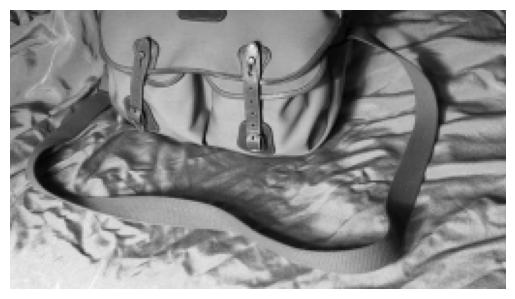

In [ ]:
plt.imshow(image.squeeze(), cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(63.5), np.float64(35.5), np.float64(-0.5))

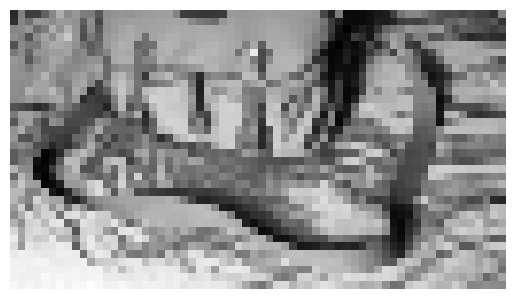

In [ ]:
plt.imshow(neuron_representations["train"][mouse_key]['images'][1].squeeze(), cmap='gray')
plt.axis('off')

In [ ]:
len(neuron_representations["train"]['k_4_a_03_b1e7_poisson']['input_neuron_tokens'])

30